/tmp/ipykernel_17/3554583010.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').dropna()


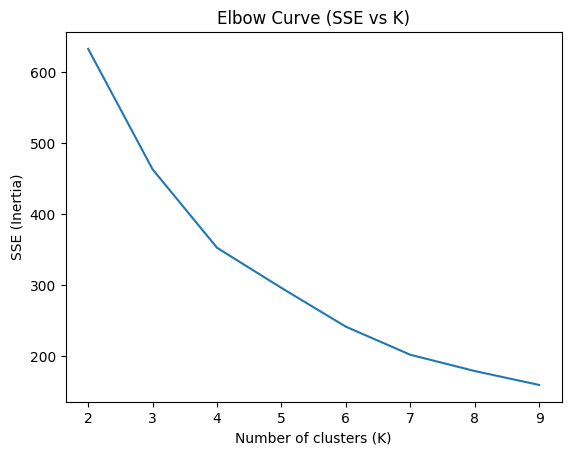

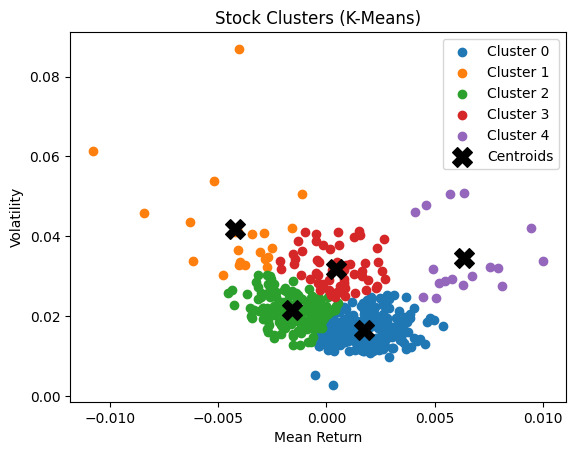


Cluster Summary:
          Returns  Volatility
Cluster                      
0        0.001737    0.016604
1       -0.004221    0.041974
2       -0.001586    0.021535
3        0.000447    0.031838
4        0.006334    0.034666

Stocks per cluster:
Cluster
0    230
2    174
3     61
1     22
4     17
Name: count, dtype: int64

Stock assignments:
A 2
AAL 3
AAP 2
AAPL 0
ABBV 0
ABC 0
ABMD 3
ABT 2
ACN 2
ADBE 2
ADI 3
ADM 0
ADP 0
ADSK 2
AEE 0
AEP 0
AES 0
AFL 0
AIG 0
AIZ 0
AJG 0
AKAM 0
ALB 3
ALGN 3
ALK 3
ALL 0
ALLE 2
AMAT 2
AMCR 0
AMD 1
AME 2
AMGN 0
AMP 2
AMT 0
AMZN 3
ANET 3
ANSS 2
ANTM 0
AON 0
AOS 2
APA 4
APD 2
APH 2
APTV 1
ARE 0
ATO 0
ATVI 0
AVB 0
AVGO 0
AVY 2
AWK 0
AXP 0
AZO 0
BA 2
BAC 2
BAX 2
BBWI 3
BBY 3
BDX 0
BEN 2
BF-B 0
BIIB 2
BIO 2
BK 2
BKNG 3
BKR 4
BLK 2
BLL 2
BMY 0
BR 2
BRK-B 0
BRO 0
BSX 0
BWA 2
BXP 0
C 2
CAG 0
CAH 0
CARR 2
CAT 0
CB 0
CBOE 0
CBRE 2
CCI 0
CCL 3
CDAY 1
CDNS 3
CDW 2
CE 2
CEG 4
CERN 0
CF 4
CFG 2
CHD 0
CHRW 2
CHTR 2
CI 0
CINF 0
CL 0
CLX 2
CMA 2
CMCSA 2
CME 0
CMG 3
CMI 2

In [2]:
# MScFE 632: Machine Learning in Finance GWP1
# Author: Eugene Ablordeppey 

# Step 1: Category 2: k-means clustering Computation
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# 1. Load dataset
df = pd.read_csv('s_and_p_500_closing.csv')

# 2. Clean data
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(method='ffill').dropna()

# 3. Compute returns
returns = df.pct_change().dropna()

# 4. Stock-level features 
features = pd.DataFrame({
    "Returns": returns.mean(),
    "Volatility": returns.std()
})

features.dropna(inplace=True)

# 5. Standardize
scaler = StandardScaler()
X = scaler.fit_transform(features)

# 6. Elbow method 
distortions = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    distortions.append(km.inertia_)
plt.figure()
plt.plot(list(K_range), distortions)
plt.title("Elbow Curve (SSE vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.show()

# 7. Fit final K-Means 
best_k = 5   
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features["Cluster"] = kmeans.fit_predict(X)

# 8. Visualization
plt.figure()

for c in range(best_k):
    cluster_data = features[features["Cluster"] == c]
    plt.scatter(cluster_data["Returns"], cluster_data["Volatility"], label=f"Cluster {c}")

centroids = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c="black", marker="X", label="Centroids")
plt.title("Stock Clusters (K-Means)")
plt.xlabel("Mean Return")
plt.ylabel("Volatility")
plt.legend()
plt.show()

# 9. Results
print("\nCluster Summary:")
print(features.groupby("Cluster").mean())

print("\nStocks per cluster:")
print(features["Cluster"].value_counts())

# Optional: stock assignment list
print("\nStock assignments:")
for stock, cluster in features["Cluster"].items():
    print(stock, cluster)

In [5]:
pip install pandas_datareader seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# MScFE 632: Machine Learning in Finance GWP1
# Author: Eugene Ablordeppey 

# Step 1: Category 2: Ridge Regression Computation
#pip install pandas_datareader seaborn
import pandas as pd
import numpy as np
import datetime
import pandas_datareader.data as web

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
start = datetime.datetime(2000, 1, 1)
end = datetime.datetime(2025, 1, 1)

In [8]:
sp500 = web.DataReader("SP500", "fred", start, end)
dgs10 = web.DataReader("DGS10", "fred", start, end)
cpi = web.DataReader("CPIAUCSL", "fred", start, end)
unrate = web.DataReader("UNRATE", "fred", start, end)
vix = web.DataReader("VIXCLS", "fred", start, end)

In [9]:
df = pd.concat([sp500, dgs10, cpi, unrate, vix], axis=1)
df.columns = ["SP500", "InterestRate", "CPI", "Unemployment", "VIX"]

df = df.dropna()
df.to_csv("financial_dataset.csv")

print("CSV saved successfully!")
print(df.head())

CSV saved successfully!
              SP500  InterestRate      CPI  Unemployment    VIX
DATE                                                           
2016-08-01  2170.84          1.51  240.545           4.9  12.44
2016-09-01  2170.86          1.57  241.176           5.0  13.48
2016-11-01  2111.72          1.83  242.026           4.7  18.56
2016-12-01  2191.08          2.45  242.637           4.7  14.07
2017-02-01  2279.55          2.48  244.006           4.6  11.81


In [10]:
df["SP500_return"] = df["SP500"].pct_change()
df = df.dropna()

In [11]:
X = df.drop(columns=["SP500_return"])
y = df["SP500_return"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

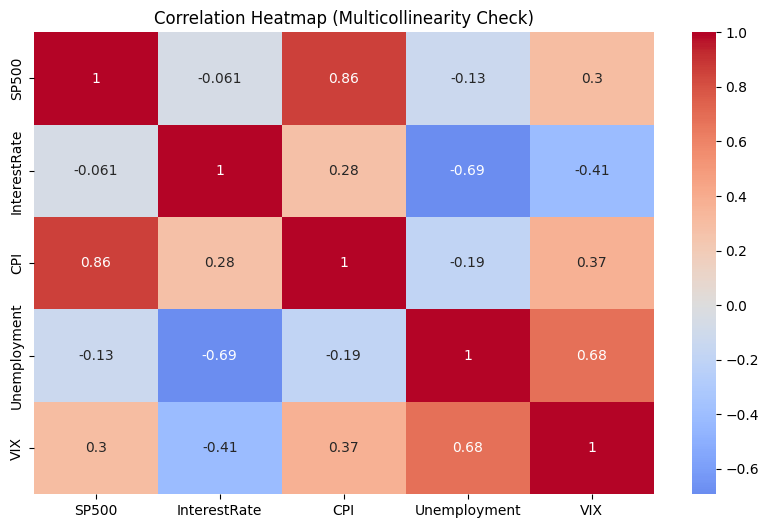

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Multicollinearity Check)")
plt.show()

In [15]:
corr_table = X_train.corr()
print(corr_table)

                 SP500  InterestRate       CPI  Unemployment       VIX
SP500         1.000000     -0.061139  0.858288     -0.128364  0.299557
InterestRate -0.061139      1.000000  0.275802     -0.693119 -0.412557
CPI           0.858288      0.275802  1.000000     -0.194291  0.365760
Unemployment -0.128364     -0.693119 -0.194291      1.000000  0.676617
VIX           0.299557     -0.412557  0.365760      0.676617  1.000000


In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1),
    "Ridge (alpha=2)": Ridge(alpha=2),
    "Ridge (alpha=3)": Ridge(alpha=3)
}

In [17]:
results = {}
coefs = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "R2": r2}
    coefs[name] = model.coef_

In [18]:
results_df = pd.DataFrame(results).T
print(results_df)

                        MSE        R2
Linear Regression  0.003130 -0.455398
Ridge (alpha=1)    0.002424 -0.126931
Ridge (alpha=2)    0.002015  0.063282
Ridge (alpha=3)    0.001781  0.172140


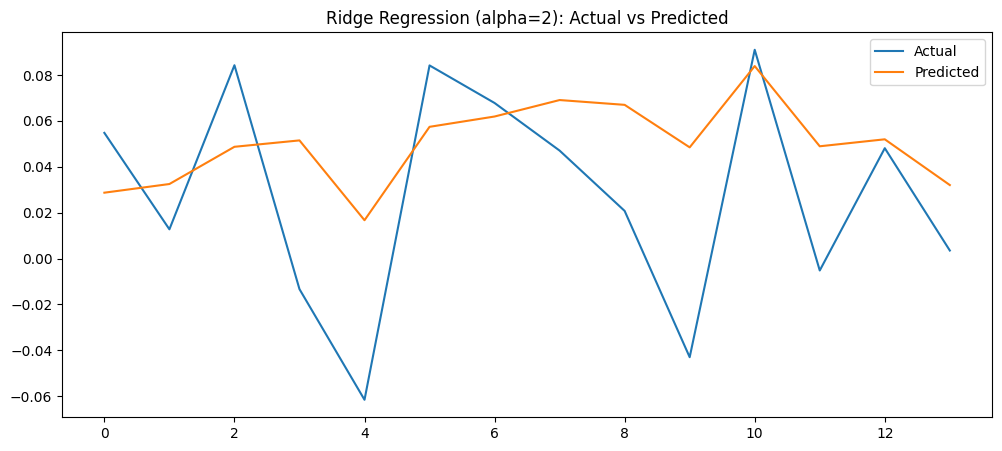

In [19]:
best_model = Ridge(alpha=2)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_best, label="Predicted")
plt.title("Ridge Regression (alpha=2): Actual vs Predicted")
plt.legend()
plt.show()

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1),
    "Ridge (alpha=2)": Ridge(alpha=2),
    "Ridge (alpha=3)": Ridge(alpha=3)
}

predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

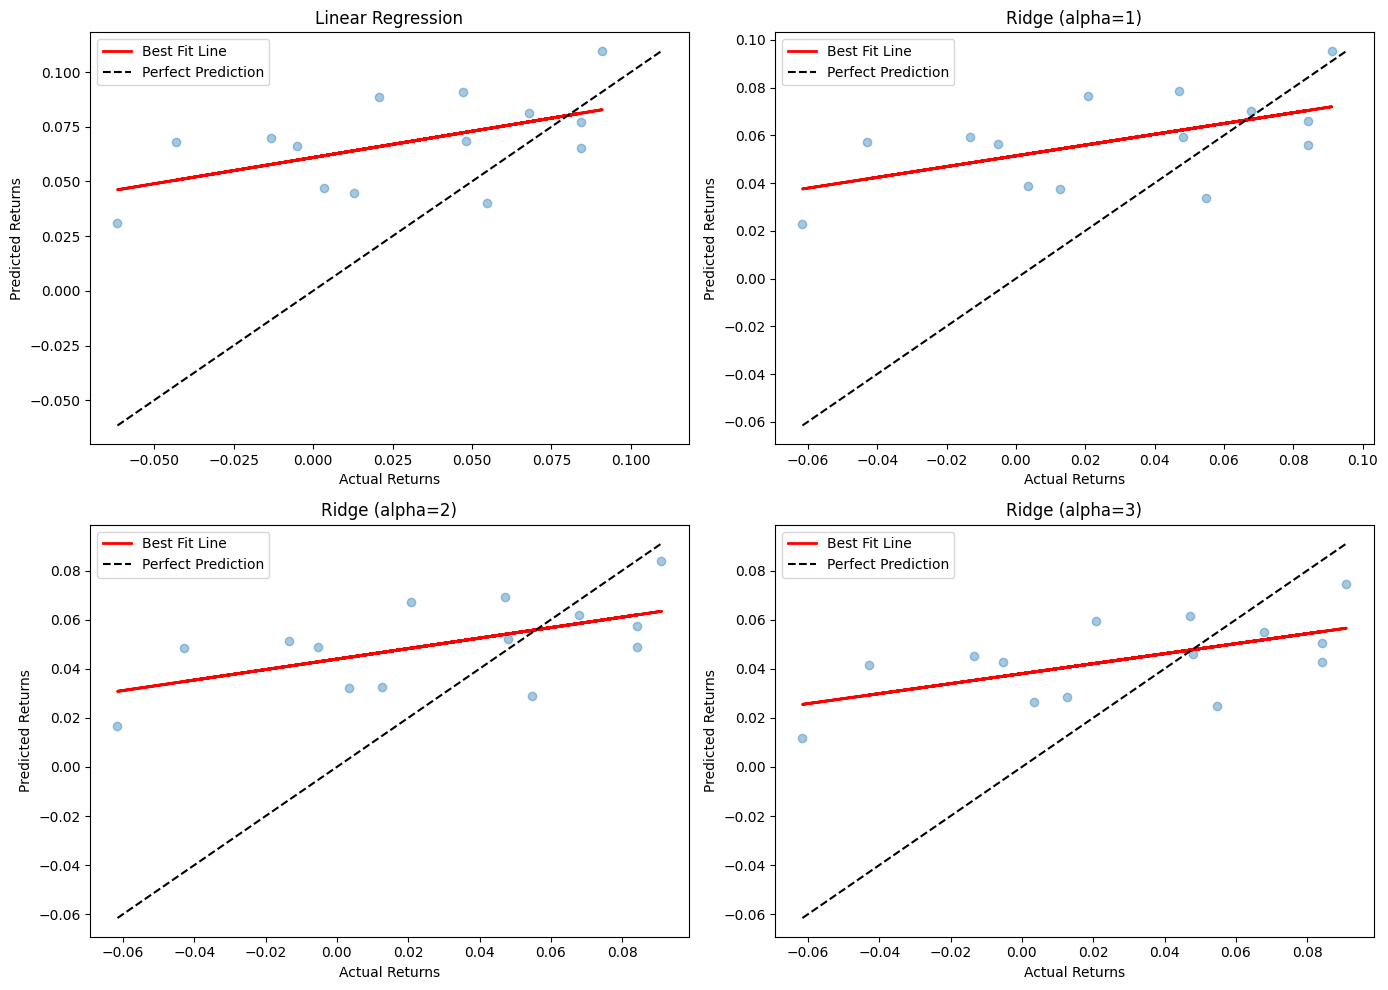

In [21]:
plt.figure(figsize=(14, 10))

for i, (name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(2, 2, i)

    # scatter plot
    plt.scatter(y_test, y_pred, alpha=0.4)

    # best-fit line (OLS line through predictions)
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    plt.plot(y_test, p(y_test), color="red", linewidth=2, label="Best Fit Line")

    # perfect prediction line (y = x)
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Perfect Prediction")

    plt.title(name)
    plt.xlabel("Actual Returns")
    plt.ylabel("Predicted Returns")
    plt.legend()

plt.tight_layout()
plt.show()